In [26]:
import matplotlib.pyplot as plt
import joblib as jlb

from collections import Counter
from pyclustering.cluster.clarans import clarans
from Algorithm import CLARANS
from pyclustering.utils import timedcall;
from Dataprepare.data_processing import D
from Dataprepare.data_processing import X_pca

In [27]:
features=[
 'balance',
 'purchases',
 'oneoff_purchases',
 'installments_purchases'
]
data=D[features]

In [28]:
print(data.shape)
print(data.tail(1))

(8636, 4)
      balance  purchases  oneoff_purchases  installments_purchases
8635 -0.18053   0.707892          1.155543               -1.096108


Time for 10 samples: 0.0099 seconds
Time for 50 samples: 0.0421 seconds
Time for 200 samples: 0.1859 seconds
Time for 500 samples: 0.2733 seconds
Time for 1000 samples: 0.6863 seconds
Time for 2000 samples: 1.5054 seconds
Time for 5000 samples: 3.8972 seconds


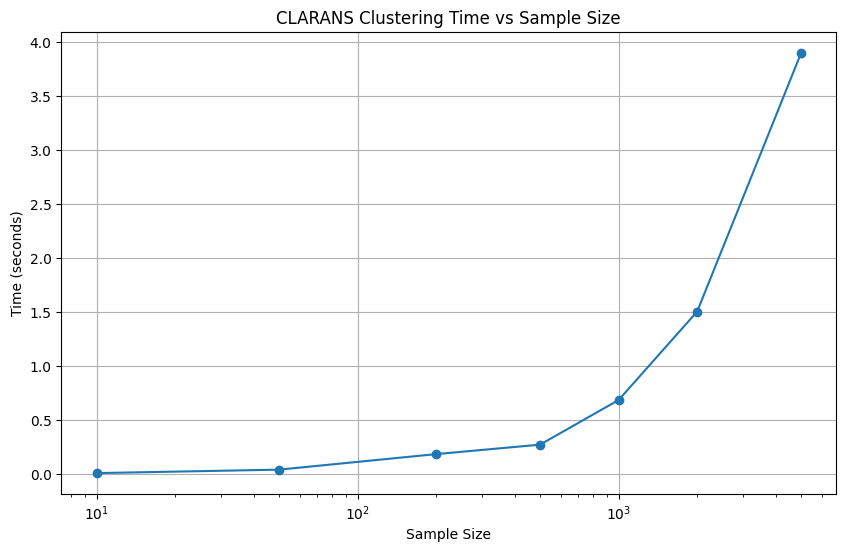

In [29]:
k = 3
n_local=5
max_nei=5
sample_sizes = [10, 50,200, 500,1000,2000,5000]
times = []
#show in plt
for size in sample_sizes:
    data_sample = data.sample(size)
    model=CLARANS(data_sample, k, n_local,max_nei)
    (ticks,results) = timedcall(model.fit)  # xây dựng mô hình 
    times.append(ticks)
    print(f"Time for {size} samples: {ticks:.4f} seconds")
plt.figure(figsize=(10, 6))
plt.plot(sample_sizes, times, marker='o')
plt.title('CLARANS Clustering Time vs Sample Size')
plt.xlabel('Sample Size')
plt.ylabel('Time (seconds)')
plt.xscale('log')
plt.grid()
plt.show()

In [30]:
#xay dung model clarans
k = 3
n_local=5
max_nei=5
# Clarans_model = clarans(datalist, number_clusters=k, numlocal=n_local, maxneighbor=max_nei)
# Clarans_model.process()
Clarans_model = CLARANS(data, k, n_local, max_nei)
Clarans_model.fit()

In [31]:
#lấy cluster và medoids
clusters = Clarans_model.get_clusters()
medoids = Clarans_model.get_medoids()

print("Clusters:", clusters)
print("Medoids:", medoids)

Clusters: [[0, 4, 6, 9, 16, 18, 19, 21, 24, 26, 28, 33, 44, 53, 57, 63, 70, 73, 75, 76, 88, 89, 90, 94, 103, 105, 108, 116, 118, 134, 137, 145, 147, 149, 153, 159, 161, 163, 164, 167, 168, 169, 176, 178, 181, 190, 192, 197, 200, 206, 210, 212, 218, 220, 221, 224, 225, 228, 229, 231, 241, 248, 250, 253, 266, 281, 288, 294, 305, 307, 308, 312, 314, 318, 322, 330, 333, 335, 341, 342, 344, 350, 355, 356, 361, 368, 376, 378, 387, 394, 399, 403, 406, 410, 412, 416, 418, 419, 430, 438, 443, 461, 467, 468, 469, 473, 480, 481, 490, 492, 500, 502, 505, 509, 517, 527, 528, 529, 530, 536, 547, 549, 556, 568, 569, 573, 578, 579, 584, 591, 593, 596, 609, 611, 614, 617, 619, 625, 626, 632, 637, 639, 643, 645, 646, 651, 656, 672, 678, 695, 700, 704, 710, 711, 715, 720, 723, 725, 741, 742, 747, 748, 750, 751, 752, 754, 768, 770, 788, 789, 790, 797, 811, 820, 823, 837, 839, 845, 850, 851, 853, 857, 861, 880, 881, 882, 887, 894, 895, 896, 899, 904, 907, 912, 920, 922, 924, 931, 948, 951, 961, 963, 971, 9

In [37]:
#gắn nhãn cluster đã có vào df
labels = [0] * len(data)

for cluster_id, cluster in enumerate(clusters):
    for index in cluster:
        labels[index] = cluster_id

data['cluster'] = labels
print(data.head(5))
print('\nKích thước clusters:', Counter(labels))
print('\n2 clusters lớn nhất:', Counter(labels).most_common(2))

    balance  purchases  oneoff_purchases  installments_purchases  cluster
0 -1.334707  -0.123312         -0.996024                0.381976        0
1  0.952729  -1.686451         -0.996024               -1.096108        1
2  0.821135   0.589495          1.049151               -1.096108        2
3  0.233137  -0.717052         -0.124918               -1.096108        1
4  0.651839   0.775749         -0.996024                1.232117        0

Kích thước clusters: Counter({2: 3372, 0: 2664, 1: 2600})

2 clusters lớn nhất: [(2, 3372), (0, 2664)]


C:\Users\Bui Thanh Tung\AppData\Local\Temp\ipykernel_16256\1084126290.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['cluster'] = labels


In [33]:
#luu model
jlb.dump(Clarans_model,'../customer_clustering/Output/clarans.mdl')

['../customer_clustering/Output/clarans.mdl']

In [34]:
#load model
Loaded_Clarans_model = jlb.load('../customer_clustering/Output/clarans.mdl')

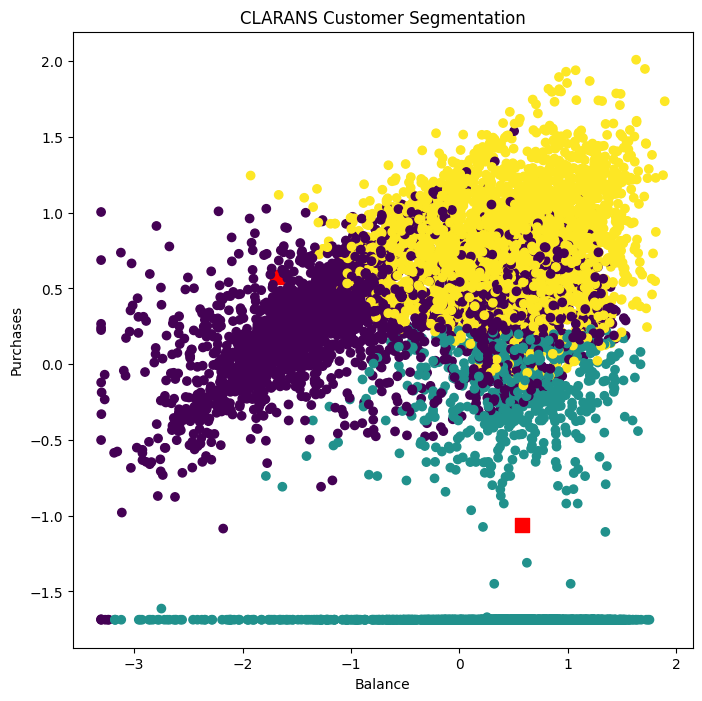

In [35]:
#hien thi model
medoid_points = data.iloc[medoids]

plt.figure(figsize=(8,8))

plt.scatter(medoid_points['purchases'],
            medoid_points['balance'],
            marker='s',
            s=100,color='red'
            )

plt.scatter(data['balance'],
            data['purchases'],
            c=data['cluster'])

plt.xlabel("Balance")
plt.ylabel("Purchases")
plt.title("CLARANS Customer Segmentation")

plt.show()

ValueError: 'c' argument has 8636 elements, which is inconsistent with 'x' and 'y' with size 1000.

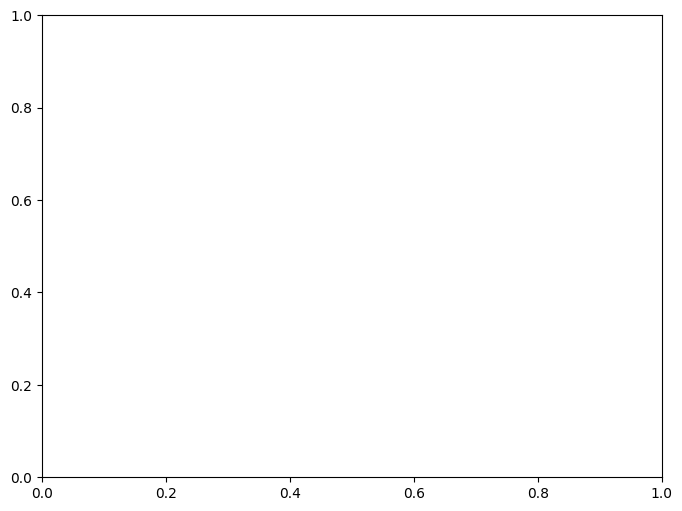

In [36]:
medoid_points = data.iloc[medoids]

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.scatter(medoid_points['purchases'],
            medoid_points['balance'],
            marker='s',
            s=100,color='red'
            )
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('CLARANS Clustering with PCA')
plt.show()